Initiation (t = 1 h)
  X = 29.9066 g/L,  S = 2.7472 g/L,  P = 37.4727 g/L,  V = 1.0500 L
Processing (t = 6 h)
  X = 30.5952 g/L,  S = 8.8181 g/L,  P = 156.0809 g/L,  V = 3.5500 L
Harvesting (t = 7 h)
  X = 34.5634 g/L,  S = 0.0000 g/L,  P = 182.5352 g/L,  V = 1.0500 L


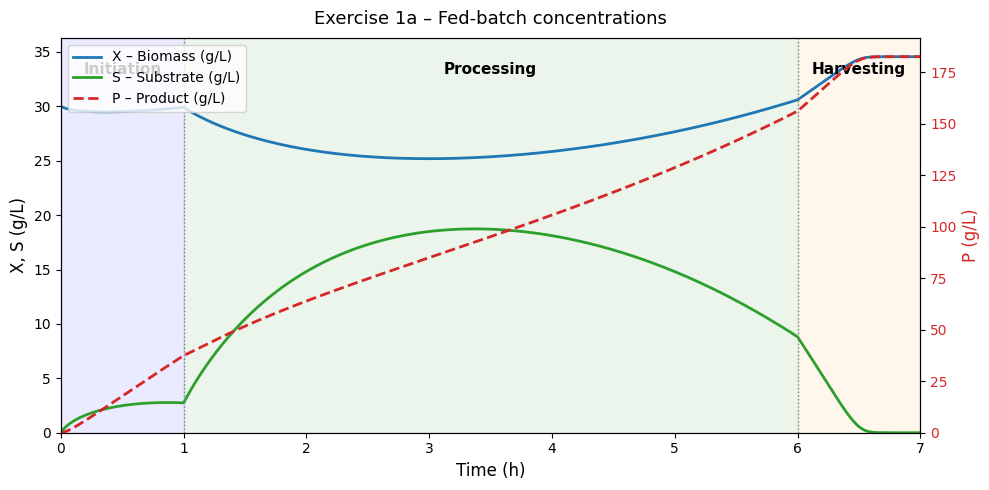

In [7]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Parameters
mu_max = 0.3
Ks     = 0.8
Ki     = 100.0
Yxs    = 0.45
Yxp    = 0.15
S0 = Sp = 80.0
FI, FP, FH = 0.2, 0.5, 2.5

def mu_net(S):
    return mu_max * S / (Ks + S + S**2 / Ki)

def odes_initiation(y, t):
    Nx, Ns, Np, V = y
    X = Nx / V
    S = max(Ns / V, 0.0)
    mu = mu_net(S)

    return [
        mu * X * V,
        FI * S0 - (mu / Yxs) * X * V,
        (mu / Yxp) * X * V,
        FI
    ]

def odes_processing(y, t):
    Nx, Ns, Np, V = y
    X = Nx / V
    S = max(Ns / V, 0.0)
    mu = mu_net(S)

    return [
        mu * X * V,
        FP * Sp - (mu / Yxs) * X * V,
        (mu / Yxp) * X * V,
        FP
    ]

def odes_harvesting(y, t):
    Nx, Ns, Np, V = y
    X = Nx / V
    S = max(Ns / V, 0.0)
    P = Np / V
    mu = mu_net(S)

    return [
        -FH * X + mu * X * V,
        -FH * S - (mu / Yxs) * X * V,
        -FH * P + (mu / Yxp) * X * V,
        -FH
    ]

# Initial conditions
y0 = [30.0 * 0.85, 0.0, 0.0, 0.85]   # [Nx, Ns, Np, V]

t_I = np.linspace(0,   1.0, 5000)
t_P = np.linspace(1.0, 6.0, 5000)
t_H = np.linspace(6.0, 7.0, 5000)

res_I = odeint(odes_initiation, y0,        t_I)
res_P = odeint(odes_processing, res_I[-1], t_P)
res_H = odeint(odes_harvesting, res_P[-1], t_H)

Nx_I, Ns_I, Np_I, V_I = res_I.T
Nx_P, Ns_P, Np_P, V_P = res_P.T
Nx_H, Ns_H, Np_H, V_H = res_H.T

def to_conc(Nx, Ns, Np, V):
    return Nx / V, np.maximum(Ns / V, 0), Np / V

X_I, S_I, P_I = to_conc(Nx_I, Ns_I, Np_I, V_I)
X_P, S_P, P_P = to_conc(Nx_P, Ns_P, Np_P, V_P)
X_H, S_H, P_H = to_conc(Nx_H, Ns_H, Np_H, V_H)

t_all = np.concatenate([t_I, t_P, t_H])
X_all = np.concatenate([X_I, X_P, X_H])
S_all = np.concatenate([S_I, S_P, S_H])
P_all = np.concatenate([P_I, P_P, P_H])

# Results
print("Initiation (t = 1 h)")
print(f"  X = {X_I[-1]:.4f} g/L,  S = {S_I[-1]:.4f} g/L,  P = {P_I[-1]:.4f} g/L,  V = {V_I[-1]:.4f} L")

print("Processing (t = 6 h)")
print(f"  X = {X_P[-1]:.4f} g/L,  S = {S_P[-1]:.4f} g/L,  P = {P_P[-1]:.4f} g/L,  V = {V_P[-1]:.4f} L")

print("Harvesting (t = 7 h)")
print(f"  X = {X_H[-1]:.4f} g/L,  S = {S_H[-1]:.4f} g/L,  P = {P_H[-1]:.4f} g/L,  V = {V_H[-1]:.4f} L")

# Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

line1, = ax1.plot(t_all, X_all, color="#1f77b4", lw=2,
                  label="X – Biomass (g/L)")

line2, = ax1.plot(t_all, S_all, color="#2ca02c", lw=2,
                  label="S – Substrate (g/L)")

ax1.set_xlabel("Time (h)", fontsize=12)
ax1.set_ylabel("X, S (g/L)", fontsize=12)
ax1.set_xlim(0, 7)
ax1.set_ylim(bottom=0)

ax2 = ax1.twinx()

line3, = ax2.plot(t_all, P_all,
                  color="#d62728",
                  lw=2,
                  ls="--",
                  label="P – Product (g/L)")

ax2.set_ylabel("P (g/L)", fontsize=12, color="#d62728")
ax2.tick_params(axis='y', labelcolor="#d62728")
ax2.set_ylim(bottom=0)

for tv in [1.0, 6.0]:
    ax1.axvline(tv, color="grey", lw=1, ls=":")

ax1.axvspan(0,   1.0, alpha=0.08, color="blue")
ax1.axvspan(1.0, 6.0, alpha=0.08, color="green")
ax1.axvspan(6.0, 7.0, alpha=0.08, color="orange")

y_text = ax1.get_ylim()[1] * 0.92

ax1.text(0.5, y_text,
         "Initiation",
         ha='center',
         va='center',
         fontsize=11,
         color="black",
         fontweight='bold')

ax1.text(3.5, y_text,
         "Processing",
         ha='center',
         va='center',
         fontsize=11,
         color="black",
         fontweight='bold')

ax1.text(6.5, y_text,
         "Harvesting",
         ha='center',
         va='center',
         fontsize=11,
         color="black",
         fontweight='bold')

lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]

ax1.legend(lines, labels, loc="upper left", fontsize=10)

plt.title("Exercise 1a – Fed-batch concentrations",
          fontsize=13,
          pad=10)

fig.tight_layout()
plt.show()